# <center>MDSA D213 Advanced Data Analytics</center> 

## <center>Task 2 Sentiment Analysis Using Neural Networks Rev I</center>

## <center>Justin Jordan</center>

## <center>8/4/2026</center>

## <center>WGU</center>



## Part I: Research Question

### A.   Describe the purpose of this data analysis by doing the following:

1.  Summarize one research question that you will answer using neural network models and NLP techniques. Be sure the research question is relevant to a real-world organizational situation and sentiment analysis captured in your chosen data set(s).

- Can we accurately classify sentiment using NLP techniques and neural network models?      

2.   Define the objectives or goals of the data analysis. Be sure the objectives or goals are reasonable within the scope of the research question and are represented in the available data.

- The goals of this analysis will be to first, preprocess the data such as cleaning.  Cleaning will consist of removing punctuation, stop words and unusual characters as well as converting to all lowercase.  The data will then be split into train, test and validation.  Next, we will train the model on the cleaned data.  The data will be vectored and padded before its fed into the model.  After we have trained the model, it will be evaluated to see how accurate the model is.  Lastly, we will provide a recommendation based on the results of the model.     

3.   Identify a type of neural network capable of performing a text classification task that can be trained to produce useful predictions on text sequences on the selected data set.

- One type of neural network capable of performing a text classification task that can be trained to produce useful predictions on text sequences of the data set is LSTM or Long Short-Term memory.  LSTM is an advanced version of RNN designed to remember information for long periods. Unlike traditional RNNs, LSTMs can retain context over longer sequences, making them ideal for text-related tasks(GeeksforGeeks, 2025).  There are three key components to a LSTM.  Forget Gate, Input Gate and Output Gate.  Forget Gate decides what information to discard.  Th input gate decides which new information to store and the output gate determines the output based on the cell state. 

## Part II: Data Preparation

### B.   Summarize the data cleaning process by doing the following:

1.   Perform exploratory data analysis on the chosen data set, and include an explanation of each of the following elements:

- presence of unusual characters (e.g., emojis, non-English characters)
- vocabulary size
- proposed word embedding length
- statistical justification for the chosen maximum sequence length


In [3]:
# import libraries and df load
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math
import scipy.stats as stats
import sklearn
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)
import re
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')
nltk.download('punkt_tab')
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('omw-1.4')
from nltk.stem import WordNetLemmatizer
from tensorflow.keras.preprocessing.text import Tokenizer
from keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dropout, Dense, Flatten, Embedding
from tensorflow.keras import optimizers
from tensorflow.keras.callbacks import EarlyStopping



[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\jjord\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\jjord\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\jjord\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\jjord\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\jjord\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [4]:


# code for data frame
amazon = pd.read_csv('C:/users/jjord/Documents/WGU/D213/d213_pa2/amazon_cells_labelled.txt', delimiter = '\t', header = None, names = ['Reviews', 'Score'])
imdb = pd.read_csv('C:/users/jjord/Documents/WGU/D213/d213_pa2/imdb_labelled.txt', delimiter = '\t|\r', header = None, names = ['Reviews', 'Score'])
yelp = pd.read_csv('C:/users/jjord/Documents/WGU/D213/d213_pa2/yelp_labelled.txt', delimiter = '\t', header = None, names = ['Reviews', 'Score'])

# Profile of Data Frame
amazon.shape



C:\Users\jjord\AppData\Local\Temp\ipykernel_17148\3678156643.py:3: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  imdb = pd.read_csv('C:/users/jjord/Documents/WGU/D213/d213_pa2/imdb_labelled.txt', delimiter = '\t|\r', header = None, names = ['Reviews', 'Score'])


(1000, 2)

In [5]:
# Profile of Data Frame
imdb.shape

(1000, 2)

In [6]:
# Profile of Data Frame
yelp.shape

(1000, 2)

In [7]:
#concat
df = pd.concat([amazon, imdb, yelp], ignore_index=True)

In [8]:
#profile concat data frame
df.shape

(3000, 2)

In [9]:
#check structure
df.head()

,Reviews,Score
0,So there is no way for me to plug it in here i...,0
1,"Good case, Excellent value.",1
2,Great for the jawbone.,1
3,Tied to charger for conversations lasting more...,0
4,The mic is great.,1


In [10]:
#check for nulls
df.isnull().sum()

Reviews    0
Score      0
dtype: int64

In [11]:
#explore
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   Reviews  3000 non-null   object
 1   Score    3000 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 47.0+ KB


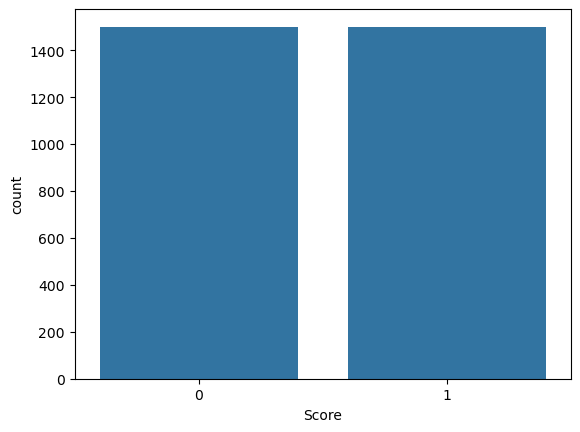

In [12]:
#plot
sns.countplot(x="Score", data = df)
plt.show()

In [13]:
#lowercase
df.Reviews = df.Reviews.str.lower()

In [14]:
#check
df.head()

,Reviews,Score
0,so there is no way for me to plug it in here i...,0
1,"good case, excellent value.",1
2,great for the jawbone.,1
3,tied to charger for conversations lasting more...,0
4,the mic is great.,1


In [15]:
#unique list before preprocessing
characters = df['Reviews']
list_of_characters = []
for comment in characters:
    for character in comment:
        if character not in list_of_characters:
            list_of_characters.append(character)
print(list_of_characters)

['s', 'o', ' ', 't', 'h', 'e', 'r', 'i', 'n', 'w', 'a', 'y', 'f', 'm', 'p', 'l', 'u', 'g', 'b', 'c', 'v', '.', 'd', ',', 'x', 'j', '4', '5', '!', 'z', 'q', '+', '"', 'k', "'", '/', '7', '3', '6', '8', '0', '2', '?', '-', '1', ':', ')', '(', '&', '$', '*', ';', '%', '9', '#', '[', ']', '\x96', 'é', '\x85', 'å', '\x97', 'ê']


In [16]:
#preprocessing
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    text = re.sub(r'[^\w\s]', '', text)  # Remove punctuation/unusual characters
    text = re.sub(r'\s+', ' ', text).strip()  # Remove extra spaces
    tokens = nltk.word_tokenize(text)  # Tokenize
    filtered_tokens = [word for word in tokens if word not in stop_words]  # Remove stopwords
    lemmatized_tokens = [lemmatizer.lemmatize(word) for word in filtered_tokens]  # Lemmatize
    return ' '.join(lemmatized_tokens)

In [17]:
df['Reviews'] = df['Reviews'].apply(preprocess_text)

In [18]:
#unique list after preprocessing
characters = df['Reviews']
list_of_characters = []
for comment in characters:
    for character in comment:
        if character not in list_of_characters:
            list_of_characters.append(character)
print(list_of_characters)

['w', 'a', 'y', ' ', 'p', 'l', 'u', 'g', 'n', 'e', 's', 'o', 'c', 'v', 'r', 't', 'd', 'x', 'j', 'b', 'i', 'h', '4', '5', 'm', 'z', 'f', 'q', 'k', '7', '3', '6', '8', '0', '2', '1', '9', 'é', 'å', 'ê']


In [19]:
#split
x = df['Reviews']
y= df['Score']

In [20]:
#train, test, validation sets
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=1234)
x_val, x_test, y_val, y_test = train_test_split(x_test, y_test, test_size=0.5, random_state=1234)

In [21]:
#make sure set have correct shape
print("x_train shape: ", x_train.shape)
print("y_train shape: ", y_train.shape)
print("x_test shape: ", x_test.shape)
print("y_test shape: ", y_test.shape)
print("x_val shape: ", x_val.shape)
print("y_val shape: ", y_val.shape)


x_train shape:  (2100,)
y_train shape:  (2100,)
x_test shape:  (450,)
y_test shape:  (450,)
x_val shape:  (450,)
y_val shape:  (450,)


In [22]:
#tokenization
tokenizer = Tokenizer()
tokenizer.fit_on_texts(x_train)
vocab_size = len(tokenizer.word_index) + 1
print(f"Vocab size is: {vocab_size}")

Vocab size is: 3912


In [23]:
#max sequence length
sequences = tokenizer.texts_to_sequences(df['Reviews'])
sequence_lengths = [len(seq) for seq in sequences]
max_sequence_length = np.max(sequence_lengths)
print("Max sequence length: ", max_sequence_length)

Max sequence length:  41


In [24]:
#Word embedding length (justify with heuristic)
embedding_length = int(math.log2(vocab_size) * 10)
print(f"Proposed Word Embedding Length: {embedding_length}")

Proposed Word Embedding Length: 119


1. (continued)

- presence of unusual characters (e.g., emojis, non-English characters)
    - As seen in the code above, the data does contain unusual characters.  We created a function called preprocess_text to remove all unusual characters as well as punctuation.  After the function was ran, you can see where it did what was expected and removed unusual characters from the data.   

- vocabulary size
    - As seen in the code above, the vocabulary size is 3912 after tokenization.  

- proposed word embedding length
    - As seen in the code above, the suggested word embedding length is 119.  There is some debate as to what the correct number should be.  Most of which will agree, use what is suggested for you sized data.  For now, we are going to stick with 119 from our calculation.    

- statistical justification for the chosen maximum sequence length
    - As seen in the code above, we tokenized the text into sequences which gave us a max sequence length of 41.  Based on the code above, choosing a max sequence length longer than 41 could skew the model.  Anything less than 41 will be handled with padding.       

2.  Describe the goals of the tokenization process, including any code generated and packages that are used to normalize text during the tokenization process.


In [25]:
#padding
x_train_seq = tokenizer.texts_to_sequences(x_train)
x_train_padded = pad_sequences(x_train_seq, maxlen=max_sequence_length, padding='post')
print(f"The shape of the padded reviews within X Train: {x_train_padded.shape}")
print(x_train_padded)

The shape of the padded reviews within X Train: (2100, 41)
[[  73  190 1544 ...    0    0    0]
 [ 700   11  331 ...    0    0    0]
 [ 105 1547  457 ...    0    0    0]
 ...
 [  26    4 3910 ...    0    0    0]
 [  29  917 3911 ...    0    0    0]
 [  30  290 1020 ...    0    0    0]]


In [26]:
x_val_seq = tokenizer.texts_to_sequences(x_val)
x_val_padded = pad_sequences(x_val_seq, maxlen=max_sequence_length, padding='post')
print(f"The shape of the padded reviews within X Val: {x_val_padded.shape}")
print(x_val_padded)

The shape of the padded reviews within X Val: (450, 41)
[[   9   94    1 ...    0    0    0]
 [1040  166    9 ...    0    0    0]
 [ 314  102   47 ...    0    0    0]
 ...
 [  26  163  786 ...    0    0    0]
 [  39  112    6 ...    0    0    0]
 [ 355   93  422 ...    0    0    0]]


In [27]:
x_test_seq = tokenizer.texts_to_sequences(x_test)
x_test_padded = pad_sequences(x_test_seq, maxlen=max_sequence_length, padding = 'post')
print(f"The shape of the padded reviews within X Test: {x_test_padded.shape}")
print(x_test_padded)

The shape of the padded reviews within X Test: (450, 41)
[[  22 1613  410 ...    0    0    0]
 [  22 1683    8 ...    0    0    0]
 [  61  105 1217 ...    0    0    0]
 ...
 [  36  268  137 ...    0    0    0]
 [1066  447   65 ...    0    0    0]
 [   5 1740  284 ...    0    0    0]]


2. (continued)
    - Code for the tokenization process is in sections B1 & B2 above.  The overall goal of tokenization is to conver the data into data that can be used in the model.  In B1, tokenization was used to word tokenize the data.  In B2, it was tokenized again into numerical so it can be interpreted by the model.    

3.  Explain the padding process used to standardize the length of sequences. Include the following in your explanation:

    - if the padding occurs before or after the text sequence
    - a screenshot of a single padded sequence

The code for padding is above in section B2.  The purpose or goal of padding is to have the same length for all sequences.  We set the maxlen equal to the max_sequence_length variable which was 41 in section B1.  Padding was done after the text sequence as seen in the code above with padding = 'post'.  

Below is output of a single padded sequence(x_train_padded).

In [28]:
x_train_padded

array([[  73,  190, 1544, ...,    0,    0,    0],
       [ 700,   11,  331, ...,    0,    0,    0],
       [ 105, 1547,  457, ...,    0,    0,    0],
       ...,
       [  26,    4, 3910, ...,    0,    0,    0],
       [  29,  917, 3911, ...,    0,    0,    0],
       [  30,  290, 1020, ...,    0,    0,    0]], dtype=int32)


4.  Identify how many categories of sentiment will be used and an activation function for the final dense layer of the network.


In [29]:
print(df['Score'].value_counts())

Score
0    1500
1    1500
Name: count, dtype: int64


4. (continued)

From the code above, Score has two values, 1 or 0.  For this reason, there will be 2 categores of sentiment.  0 represents negative, 1 represents postive.  

The activation function for the final dense layer of the network used will be a sigmoid activation function.  Sigmoid is typically used for binary classification where we only have 2 classes.  Sigmoid functions transform data by mapping input values to a range between 0 and 1. The output of a sigmoid function can be interpreted as a value that represents the probability or intensity of an event. This makes sigmoid functions useful for representing relationships in data, as they can provide a measure of how likely or strong something is based on the input(Codecademy, 2023).   

5.  Explain the steps used to prepare the data for analysis, including the size of the training, validation, and test set split (based on the industry average).

    - First we imported the necessary libraries needed.  
    - loaded files into separate data frames
    - concatenated into one data frame using concat() function in pandas
    - explored data frame using shape() function to look at structure and isnull().sum() function to check for nulls
    - made all words lowercase using the str.lower() function
    - checked for unusual characters
    - created function to remove unusual characters, punctuation, extra spaces, defined stop words and also lemmatizes and tokenizes text
    - ran function created on 'Reviews' column of data frame
    - split data into train, test and val using a 70/30 split.  With test split again for val, it becomes a 70/15/15 split.
    - tokanization again to determine vocab size and max sequence length
    - word embedding length based on heuristic
    - train, test and val tokenized/vectored and padded
    - checked output
    - data exported to CSV       

6.  Provide a copy of the prepared data set.
    - code below for export of data set.  All will be attached to submission in .zip folder named "files".        
        
        

In [30]:
#export cleaned data frame
df.to_csv('cleaned_data.csv', index=False)

#convert padded data and labels to Dataframes
train_data = pd.DataFrame(x_train_padded)
train_data['y'] = y_train.values

val_data = pd.DataFrame(x_val_padded)
val_data['y'] = y_val.values


test_data = pd.DataFrame(x_test_padded)
test_data['y'] = y_test.values

#combine into one data frame
prepared_data = pd.concat([train_data, val_data, test_data], ignore_index = True)

#export to CSV
prepared_data.to_csv('prepared_data.csv', index = False)


train_data.to_csv('x_train_padded.csv', index = False)
y_train.to_csv('y_train.csv', index = False)
val_data.to_csv('X_val_padded.csv', index = False)
y_val.to_csv('y_val.csv', index = False)
test_data.to_csv('X_test_padded.csv', index = False)
y_test.to_csv('y_test.csv', index = False)

## Part III: Network Architecture

### C.  Describe the type of network used by doing the following:

1.  Provide the output of the model summary of the function from TensorFlow.


In [42]:
#c1 code
model = Sequential()
model.add(Embedding(vocab_size, embedding_length, input_length= max_sequence_length))
model.add(LSTM(128))
model.add(Dense(units=1, activation='sigmoid'))
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.build(input_shape =(None, max_sequence_length))
model.summary()

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_9 (Embedding)         │ (None, 41, 119)        │       465,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_8 (LSTM)                   │ (None, 128)            │       126,976 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 592,633 (2.26 MB)

 Trainable params: 592,633 (2.26 MB)

 Non-trainable params: 0 (0.00 B)


2.  Discuss the number of layers, the type of layers, and the total number of parameters.

- There is a total of 3 layers, one embedding layer, one LSTM layer and one dense layer.  The embedding layer converts words into dense vectors.  The LTSM layer processes the sequential input.  The dense layer produces the final output.  The total number of parameters in the model is 592,633.   

3.  Justify the choice of hyperparameters, including the following elements:

    - activation functions
    - number of nodes per layer
    - loss function
    - optimizer
    - stopping criteria
    - evaluation metric

 


In [43]:
#early stop
early_stopping = EarlyStopping(monitor = 'val_accuracy', patience=2)

- activation functions

    - The activation function used was sigmoid activation function.  Sigmoid is typically used for binary classification.  Sigmoid functions transform data by mapping input values to a range between 0 and 1. The output of a sigmoid function can be interpreted as a value that represents the probability or intensity of an event. This makes sigmoid functions useful for representing relationships in data, as they can provide a measure of how likely or strong something is based on the input(Codecademy, 2023).    

- number of nodes per layer

    - The number of nodes for the input layer(embedding) was the vocab size(3192) which is the dimensionality of the input data.  The LSTM layer nodes were chosen by experimentation in powers of 2.  128, 256, 512, etc.  Once we got over 128, the model accuary was reduced so 128 was the number used.  The number of nodes used for the dense layer is 1.     

- loss function

    - Binary crossentropy was used as the loss function.  Since our data is binary classification, binary crossentropy was used.  Binary crossentropy is good for classification analysis, for those whose rating sentiments operate a binary 1 or 0 classification(Sewell).

- optimizer

    - The optimizer used was "adam".  The ‘adam’ optimizer is more popular than other optimization algorithms used in deep learning(Sewell).  It presented no issues with the model.  

- stopping criteria

    - The stopping criteria of validation accuracy is useful because it can helps the model handle unseen data well, while also attempting to limit overfitting. By assessing the model performance on a dataset not seen during training, we can help ensure that the model isn’t memorizing patterns in the training data instead of learning the more generalized features of the data. Choosing a patience value of 2 helps make sure that training stops when improvements in performance start to level off.

- evaluation metric

    - The evaluation metric of accuracy is an easy to interpret metric. In terms of binary classification, this metric matches our overall goal of maximizing the number of correct predictions the model makes.

## Part IV: Model Evaluation

### D.  Evaluate the model training process and its relevant outcomes by doing the following:

1.  Discuss the impact of using stopping criteria to include defining the number of epochs, including a screenshot showing the final training epoch.


In [44]:
#model fit
history = model.fit(x_train_padded, y_train, validation_data=(x_val_padded, y_val),
                    epochs=50, callbacks=[early_stopping])

Epoch 1/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.5067 - loss: 0.6939 - val_accuracy: 0.4956 - val_loss: 0.6956
Epoch 2/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.5010 - loss: 0.6936 - val_accuracy: 0.5044 - val_loss: 0.6931
Epoch 3/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.5038 - loss: 0.6934 - val_accuracy: 0.4956 - val_loss: 0.6932
Epoch 4/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.5248 - loss: 0.6864 - val_accuracy: 0.6489 - val_loss: 0.6185
Epoch 5/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.7314 - loss: 0.5547 - val_accuracy: 0.6800 - val_loss: 0.6089
Epoch 6/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.7724 - loss: 0.5319 - val_accuracy: 0.7022 - val_loss: 0.6189
Epoch 7/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.7929 - loss: 0.5136 - val_accuracy: 0.7067 - val_loss: 0.6310
Epoch 8/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.8119 - loss: 0.4869 - val_accuracy: 0.7156 - v

- An early stopping with a patience of 2 will stop the model from training after 2 epochs that do not improve model accuracy.  This is done to prevent overfitting and same time.    

2.  Assess the fitness of the model and any actions taken to address overfitting.


In [45]:
#d2 accuracy
score = model.evaluate(x_test_padded, y_test, verbose = 0)
print(f'Test loss: {score[0]} / Test accuracy: {score[1]}')

Test loss: 0.6509156823158264 / Test accuracy: 0.7066666483879089


- The test accuracy is 0.7066666483879089 or 71%(rounded).  This is a fairly accurate model for correctly classifing if the review sentiment is positive or negative.  The test loss is 0.6509156823158264 or 65%(rounded).  That is higher than we would like as we would prefer to see that be much lower.  Overfitting was addressed by using an early stop as well and reducing the number of layers.  Despite our efforts, it still appears the model overfit based on the test loss of 65%. 

3.  Provide visualizations of the model’s training process, including a line graph of the loss and chosen evaluation metric.


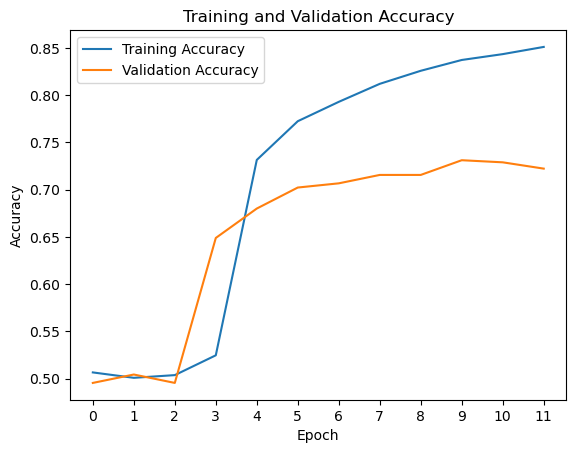

In [46]:
#visualization of accuracy
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Training and Validation Accuracy")
plt.xticks(range(len(history.history["accuracy"])))
plt.show()

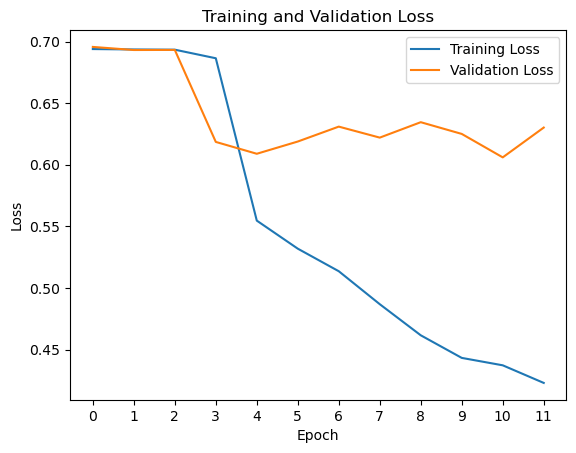

In [47]:
#visualization of loss
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Training and Validation Loss")
plt.xticks(range(len(history.history["loss"])))
plt.show()

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


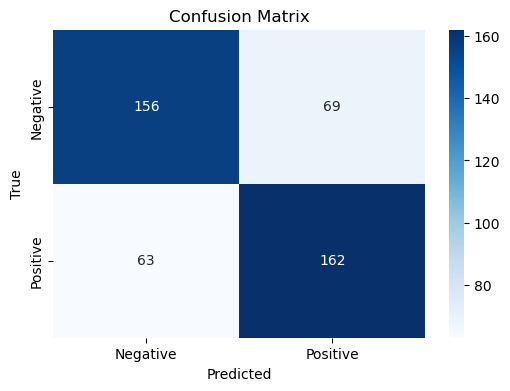

In [48]:
#eval 
y_pred = model.predict(x_test_padded)
y_pred_classes = (y_pred > 0.5).astype("int32")  
conf_matrix = confusion_matrix(y_test, y_pred_classes)

plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

In [49]:
TP = 162
TN = 156
FP = 69
FN = 63

accuracy = (TP+TN) / (TP+TN+FP+FN)
accuracy

0.7066666666666667


4.  Discuss the predictive accuracy of the trained network using the chosen evaluation metric from part D3.
    - Earlier in section D2, we stated the loss was roughly 65% and the accuracy was roughly 71%.  The confusion matrix above shows the model was better at determining positive sentiment than negative.  With the accuracy roughly 71%, we can consider this model accurate.  In one of Dr. Sewell's webinars, he stated anything over 70% is considered good and should be turned in and this is just barely over.  



## Part V:  Summary and Recommendations

### E. Provide the code you used to save the trained network within the neural network.

- code is below


In [50]:
#model h5
model.save('Sentiment Analysis Model.h5')

#model keras
model.save('Sentiment Analysis Model.keras')


### F. Discuss the functionality of your neural network, including the impact of the network architecture.

- Overall, functionalitly of the neurel network was good.  The accuracy of 71% shows it does well for sentiment analysis but there is still room for improvement, especially in the loss at 65%.  The network was trained on 2100 of the 3000 reviews and their sentiments.  Test and val were 450 each.  The setup of the network architecture seemed to be the best option for binary classification.  The sigmoid activation function, binary crossentropy loss function, number of nodes in the dense layer and the stop function based off of accuracy are all network architecture choices that create an accurate model for binary classification problems.  Different architecture would be potentially helpful in improving the model.  Adding more dense layers or adding a dropout layer could help with overfitting.  Adjusting hyperparameters could also improve the performance and lower the test loss.     

### G. Recommend a course of action based on your results.

- The recommended course of action based on the results would be to futher fine tune the model.  The accuracy of 71% is good but could still be better and the test loss could be improved as well from the 65%.  Different architecture would be potentially helpful in improving the model and reducing test loss.  Adjusting hyperparameters could also improve the performance and lower the test loss.  Splitting the data 80/20(80/10/10) isntead of the 70/30(70/15/15) used in this analysis would also be a recommendation to see if the different split could improve accuarcy and lower test loss.  Overall, the model is a good foundation to keep building on.      


## Part VI: Reporting

### H.   Show your neural network in an industry-relevant interactive development environment (e.g., a Jupyter Notebook). Include a PDF or HTML document of your executed notebook presentation.

- This notebook has been submitted in both .ipynb and PDF file types.



### I.  Denote specific web sources you used to acquire segments of third-party code that was used to support the application.
    None used.

### J.  Acknowledge sources, using in-text citations and references, for content that is quoted, paraphrased, or summarized.
    WGU. (n.d.). Churn Data Consideration and Dictionary. Data Files and Associated Dictionary Files. https://access.wgu.edu/ASP3/aap/content/s8dj4edjf84hd8fcvn3d.zip

    Stryker, C. (2025, November 17). What is a recurrent neural network (RNN)?. IBM. https://www.ibm.com/think/topics/recurrent-neural-networks 

    Codecademy. (2023, July 7). Ai: Neural networks: Sigmoid activation function. https://www.codecademy.com/resources/docs/ai/neural-networks/sigmoid-activation-function

    Sewell, W. (n.d.). D213 SA Webinar 5. https://westerngovernorsuniversity-my.sharepoint.com/:b:/g/personal/sbishop2_wgu_edu/Ea15IDBaWXRKobuOQV81-PEBz1Sl1AZwVvv62Xmn_G8I2A?e=JEEns4 

    GeeksforGeeks. (2026, April 15). ReLU activation function in deep learning. https://www.geeksforgeeks.org/deep-learning/relu-activation-function-in-deep-learning/ 

    GeeksforGeeks. (2025, June 5). Sentiment analysis using LSTM. https://www.geeksforgeeks.org/nlp/sentiment-analysis-using-lstm/ 




     

### K.  Demonstrate professional communication in the content and presentation of your submission.

    